In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import math
import soundfile as sf
import random
from tqdm.notebook import tqdm as tqdm

In [26]:
pickle_file = "beta_zerooneeight.pth"
beta  = "0.018"

In [27]:
device="cpu" 

In [28]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [29]:
def sin(t):
    return np.sin(t)

def saw(t):
    return ( ((t-np.pi)/(2*np.pi))%1 - .5) *2

def square(t):
    return np.sign(np.sin(t))

def tri(t):
    sw = saw(t+np.pi/2)*2
    return sw * np.sign(sw)- 1

In [30]:
def create_waveforms(fn=sin, fs=512, duration=1024, period=440, phase=0, amplitude=1):
    period = np.array(period)
    period = np.reshape(period, (period.size, 1))

    phase = np.array(phase)
    phase = np.reshape(phase, (phase.size, 1))

    amplitude = np.array(amplitude)
    amplitude = np.reshape(amplitude, (amplitude.size, 1))

    t = (np.arange(0, duration, 1)/fs)[None,:]
    x = amplitude * fn(2*np.pi*(phase + t*period))
    return x, t
    

In [31]:
input_length = 256

np.random.seed(0)

# convert it into np.arrange instead of hardcoding
periods_train = [
    261.63, 277.18, 293.66, 311.13, 329.63, 349.23, 369.99, 392.0, 415.3, 440.0,
    466.16, 493.88, 523.25, 554.37, 587.33, 622.25, 659.25, 698.46, 739.99, 783.99,
    830.61, 880.0, 932.33, 987.77, 1046.5, 1108.73, 1174.66, 1244.51, 1318.51, 1396.91,
    1479.98, 1567.98, 1661.22, 1760.0, 1864.66, 1975.53
]
n_samples_train = len(periods_train)

half_index = len(periods_train) // 2
periods_sin = periods_train[:half_index]
periods_saw = periods_train[half_index:]

var_sin, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=periods_train, amplitude=1)
var_square, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=periods_train, amplitude=1)
var_saw, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=periods_train, amplitude=1)
var_triangle, _ = create_waveforms(fn=tri, fs=22050, duration=input_length, phase=0, period=periods_train, amplitude=1)


x_sin, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=periods_train[0*n_samples_train//4:1*n_samples_train//4], amplitude=1)
x_saw, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=periods_train[1*n_samples_train//4:2*n_samples_train//4], amplitude=1)
x_tri, _ = create_waveforms(fn=tri, fs=22050, duration=input_length, phase=0, period=periods_train[2*n_samples_train//4:3*n_samples_train//4], amplitude=1)
x_square, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=periods_train[3*n_samples_train//4:4*n_samples_train//4], amplitude=1)

var_all_shape = torch.tensor(np.concatenate([x_sin,x_square, x_tri, x_saw], axis=0), dtype=torch.float32)

var_sin_saw = torch.tensor(np.concatenate([var_sin, var_saw], axis=0), dtype=torch.float32)
 # x_square, x_tri,

In [32]:
var_sin_saw

tensor([[ 0.0000,  0.0745,  0.1486,  ...,  0.0121,  0.0865,  0.1605],
        [ 0.0000,  0.0789,  0.1573,  ...,  0.9057,  0.9364,  0.9611],
        [ 0.0000,  0.0836,  0.1666,  ...,  0.7314,  0.6718,  0.6076],
        ...,
        [ 0.0000,  0.1596,  0.3193,  ...,  0.3882,  0.5478,  0.7075],
        [ 0.0000,  0.1691,  0.3383,  ...,  0.7899,  0.9591, -0.8718],
        [ 0.0000,  0.1792,  0.3584,  ..., -0.6658, -0.4867, -0.3075]])

In [33]:
var_sin.shape
epsilon = 1e-10

In [34]:
# fft_sin = np.fft.fft(var_sin, axis=1)
# power_spectrum_sin = np.abs(fft_sin) ** 2
# frequencies_sin = np.fft.fftfreq(input_length, 1/22050)

# fft_sqaure = np.fft.fft(var_square, axis=1)
# power_spectrum_square = np.abs(fft_sqaure) ** 2
# frequencies_square = np.fft.fftfreq(input_length, 1/22050)

fft_saw = np.fft.fft(var_saw, axis=1)
power_spectrum_saw = np.abs(fft_saw) ** 2
frequencies_saw = np.fft.fftfreq(input_length, 1/22050)

# fft_tri = np.fft.fft(var_triangle, axis=1)
# power_spectrum_tri = np.abs(fft_tri) ** 2
# frequencies_tri = np.fft.fftfreq(input_length, 1/22050)



In [35]:
class VAE(torch.nn.Module):
    def __init__(self, input_dim=512, latent_dim=2, hidden_dims=[128, 64, 36]):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1],hidden_dims[2]),
            torch.nn.Tanh(),
            
        )

        self.z_mean = torch.nn.Linear(hidden_dims[2], latent_dim)
        self.z_log_var = torch.nn.Linear(hidden_dims[2], latent_dim)


        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dims[2]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1], hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], input_dim),
        )


    def reparameterize(self, z_mu, z_log_var):
        device = z_mu.device
        # Sampling the eps from the standard multivariate normal distribution in each forward pass
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device)
        # reparameterized_mean = mean_vector + random noise(eps) + log variance
        z = z_mu + eps * torch.exp(z_log_var / 2.0)
        return z

    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded,z_mean,z_log_var,decoded
        

In [36]:
AE = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
AE.load_state_dict(torch.load("beta_zero.pth"))
good_VAE = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
good_VAE.load_state_dict(torch.load("beta_zerooneeight.pth"))
BAE = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
BAE.load_state_dict(torch.load("beta_zerotwo.pth"))

<All keys matched successfully>

In [37]:
x = AE.encoder(torch.Tensor(var_sin))
z_mean, z_log_var = AE.z_mean(x), AE.z_log_var(x)
AE_encoded_orig_sin = AE.reparameterize(z_mean, z_log_var)

x = AE.encoder(torch.Tensor(var_saw))
z_mean, z_log_var = AE.z_mean(x), AE.z_log_var(x)
AE_encoded_orig_saw = AE.reparameterize(z_mean, z_log_var)

AE_encoded_avg = (AE_encoded_orig_sin + AE_encoded_orig_saw)/2

In [38]:
x = good_VAE.encoder(torch.Tensor(var_sin))
z_mean, z_log_var = good_VAE.z_mean(x), good_VAE.z_log_var(x)
good_AE_encoded_orig_sin = good_VAE.reparameterize(z_mean, z_log_var)

x = good_VAE.encoder(torch.Tensor(var_saw))
z_mean, z_log_var = good_VAE.z_mean(x), good_VAE.z_log_var(x)
good_AE_encoded_orig_saw = good_VAE.reparameterize(z_mean, z_log_var)


good_VAE_encoded_avg = (good_AE_encoded_orig_sin + good_AE_encoded_orig_saw) /2

In [39]:
x = BAE.encoder(torch.Tensor(var_sin))
z_mean, z_log_var = BAE.z_mean(x), BAE.z_log_var(x)
BAE_encoded_orig_sin = BAE.reparameterize(z_mean, z_log_var)

x = BAE.encoder(torch.Tensor(var_saw))
z_mean, z_log_var = BAE.z_mean(x), BAE.z_log_var(x)
BAE_encoded_orig_saw = BAE.reparameterize(z_mean, z_log_var)




BAE_encoded_avg = (BAE_encoded_orig_sin+BAE_encoded_orig_saw)/2

In [42]:
# Decoding for all three models (sin, avg, saw)

# Decoding for AE model
AE_decoded_sin = AE.decoder(AE_encoded_orig_sin).detach().numpy()
AE_decoded_avg = AE.decoder(AE_encoded_avg).detach().numpy()
AE_decoded_saw = AE.decoder(AE_encoded_orig_saw).detach().numpy()

# Decoding for good_VAE model
good_VAE_decoded_sin = good_VAE.decoder(good_AE_encoded_orig_sin).detach().numpy()
good_VAE_decoded_avg = good_VAE.decoder(good_VAE_encoded_avg).detach().numpy()
good_VAE_decoded_saw = good_VAE.decoder(good_AE_encoded_orig_saw).detach().numpy()

# Decoding for BAE model
BAE_decoded_sin = BAE.decoder(BAE_encoded_orig_sin).detach().numpy()
BAE_decoded_avg = BAE.decoder(BAE_encoded_avg).detach().numpy()
BAE_decoded_saw = BAE.decoder(BAE_encoded_orig_saw).detach().numpy()


In [43]:
# Assume input_length is defined as the length of the input signal
input_length = AE_decoded_sin.shape[1]  # Assuming all decoded outputs have the same length

# FFT and power spectrum for AE model
ae_fft_sin = np.fft.fft(AE_decoded_sin, axis=1)
ae_fft_sin_power_spectrum = np.abs(ae_fft_sin) ** 2

ae_fft_avg = np.fft.fft(AE_decoded_avg, axis=1)
ae_fft_avg_power_spectrum = np.abs(ae_fft_avg) ** 2

ae_fft_saw = np.fft.fft(AE_decoded_saw, axis=1)
ae_fft_saw_power_spectrum = np.abs(ae_fft_saw) ** 2

# FFT and power spectrum for good_VAE model
good_vae_fft_sin = np.fft.fft(good_VAE_decoded_sin, axis=1)
good_vae_fft_sin_power_spectrum = np.abs(good_vae_fft_sin) ** 2

good_vae_fft_avg = np.fft.fft(good_VAE_decoded_avg, axis=1)
good_vae_fft_avg_power_spectrum = np.abs(good_vae_fft_avg) ** 2

good_vae_fft_saw = np.fft.fft(good_VAE_decoded_saw, axis=1)
good_vae_fft_saw_power_spectrum = np.abs(good_vae_fft_saw) ** 2

# FFT and power spectrum for BAE model
bae_fft_sin = np.fft.fft(BAE_decoded_sin, axis=1)
bae_fft_sin_power_spectrum = np.abs(bae_fft_sin) ** 2

bae_fft_avg = np.fft.fft(BAE_decoded_avg, axis=1)
bae_fft_avg_power_spectrum = np.abs(bae_fft_avg) ** 2

bae_fft_saw = np.fft.fft(BAE_decoded_saw, axis=1)
bae_fft_saw_power_spectrum = np.abs(bae_fft_saw) ** 2

# Frequency calculation (assuming the same sampling rate of 22050 Hz)
sampling_rate = 22050
frequencies = np.fft.fftfreq(input_length, 1/sampling_rate)


In [17]:
# orig_saw = np.fft.fft(var_saw, axis=1)
# orig_saw_power_spectrum = np.abs(orig_saw) ** 2
# orig_frequencies = np.fft.fftfreq(input_length, 1/22050)

In [18]:
# ae_fft_saw = np.fft.fft(AE_output, axis=1)
# ae_fft_saw_power_spectrum = np.abs(ae_fft_saw) ** 2
# ae_frequencies = np.fft.fftfreq(input_length, 1/22050)

In [19]:
# vae_fft_sin = np.fft.fft(VAE_output, axis=1)
# vae_fft_sin_power_spectrum = np.abs(vae_fft_sin) ** 2
# vae_frequencies = np.fft.fftfreq(input_length, 1/22050)

In [20]:
# bae_fft_sin = np.fft.fft(BAE_output, axis=1)
# bae_fft_sin_power_spectrum = np.abs(bae_fft_sin) ** 2
# bae_frequencies = np.fft.fftfreq(input_length, 1/22050)

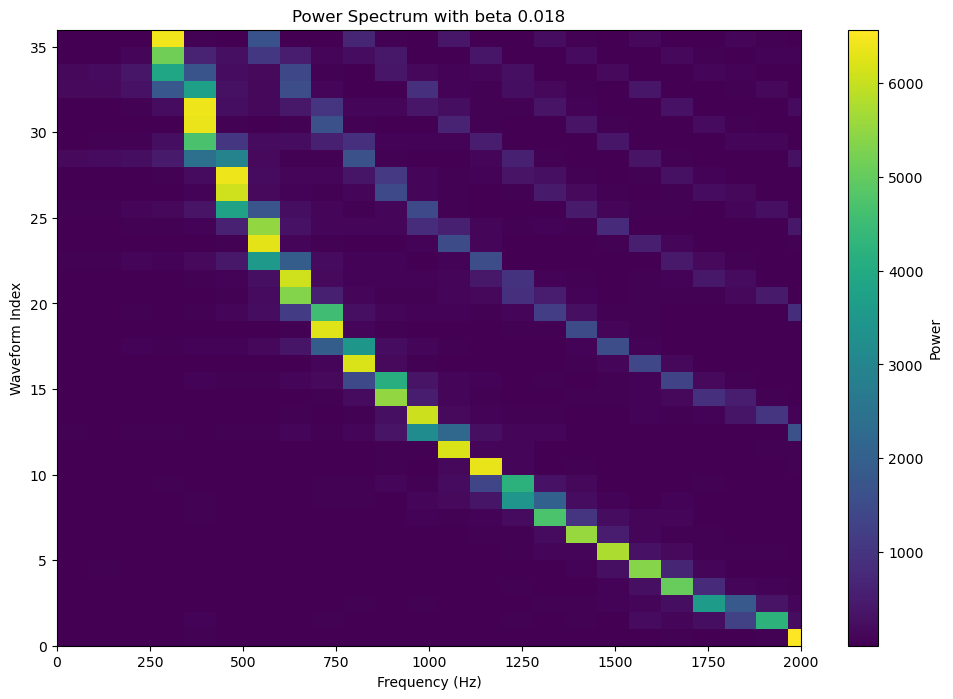

In [21]:
plt.figure(figsize=(12, 8))
plt.imshow(orig_saw_power_spectrum[:, :input_length // 2], aspect='auto', cmap='viridis',
           extent=[orig_frequencies[0], orig_frequencies[input_length // 2 - 1], 0, n_samples_train])
plt.colorbar(label='Power')
plt.title(f'Power Spectrum with beta {beta}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Waveform Index')
plt.xlim(0,2000)
plt.show()

In [22]:
n_sin = var_sin.shape[0]  # Total number of sine waves
n_saw = var_saw.shape[0]  # Total number of saw waves

# Create masks or index ranges for sine and saw waves
sin_indices = list(range(0, n_sin))
saw_indices = list(range(n_sin, n_sin + n_saw))

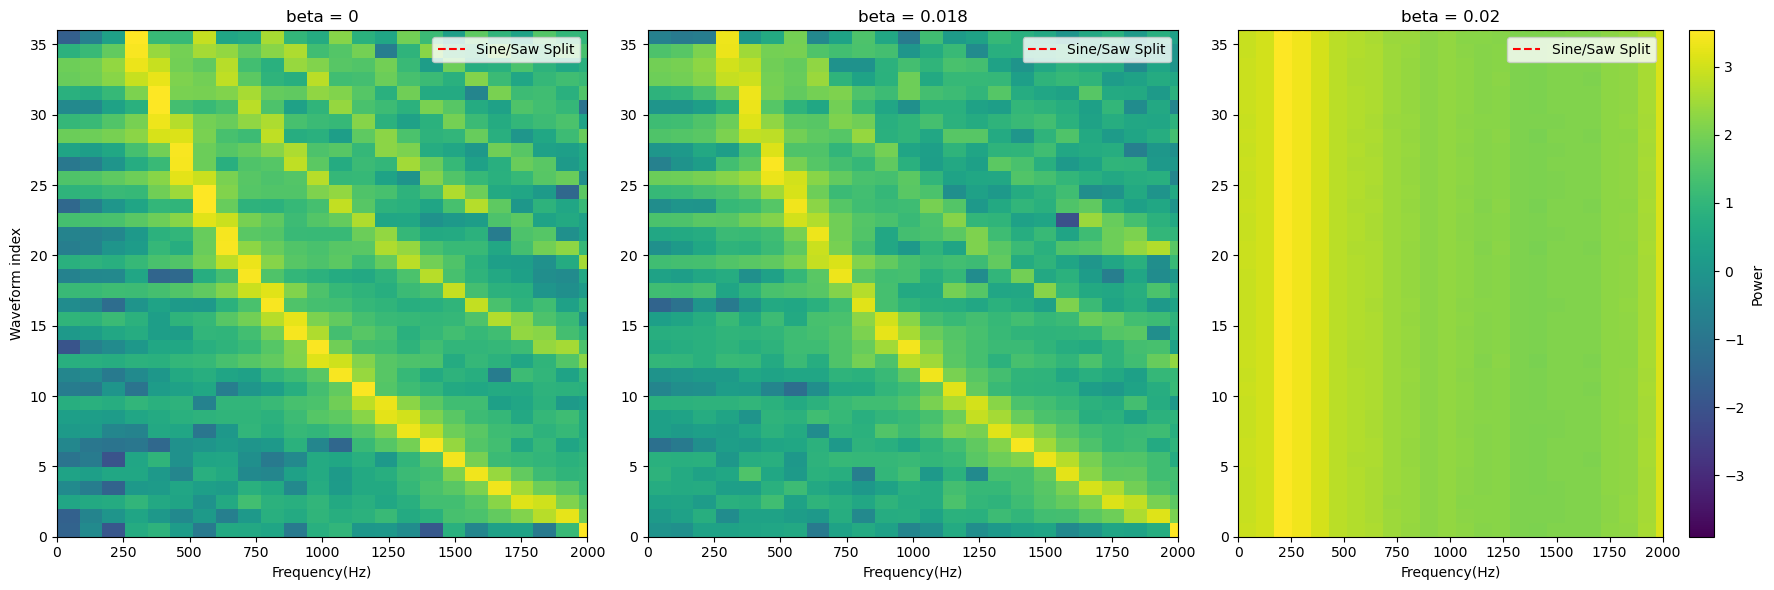

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # Create a 1x3 grid for subplots

# Number of sine and saw waves (assuming same n_samples_train for both saw and sin)
n_sin = len(sin_indices)
n_saw = len(saw_indices)

# AE saw plot
axs[0].imshow(np.log(ae_fft_saw_power_spectrum[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
              extent=[ae_frequencies[0], ae_frequencies[input_length // 2 - 1], 0, n_samples_train])
axs[0].set_title("beta = 0")
axs[0].set_xlim(0, 2000)
axs[0].set_ylabel("Waveform index")
axs[0].set_xlabel("Frequency(Hz)")
# Add horizontal line indicating where sine waves end and saw waves begin
axs[0].axhline(y=n_sin, color='red', linestyle='--', label='Sine/Saw Split')

# VAE sin plot
axs[1].imshow(np.log(vae_fft_sin_power_spectrum[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
              extent=[vae_frequencies[0], vae_frequencies[input_length // 2 - 1], 0, n_samples_train])
axs[1].set_title("beta = 0.018")
axs[1].set_xlabel("Frequency(Hz)")
axs[1].set_xlim(0, 2000)
# Add horizontal line indicating where sine waves end and saw waves begin
axs[1].axhline(y=n_sin, color='red', linestyle='--', label='Sine/Saw Split')

# BAE sin plot
im_bae =axs[2].imshow(np.log(bae_fft_sin_power_spectrum[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
              extent=[bae_frequencies[0], bae_frequencies[input_length // 2 - 1], 0, n_samples_train])
axs[2].set_title("beta = 0.02")
axs[2].set_xlabel("Frequency(Hz)")
axs[2].set_xlim(0, 2000)
fig.colorbar(im_bae, ax=axs[2], label='Power')# Add horizontal line indicating where sine waves end and saw waves begin
axs[2].axhline(y=n_sin, color='red', linestyle='--', label='Sine/Saw Split')

# Add a common legend to indicate the meaning of the line
for ax in axs:
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("test_interpolations.png", bbox_inches="tight")
plt.show()


In [24]:
# fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # Create a 1x3 grid for subplots

# # AE saw plot
# axs[0].imshow(np.log(ae_fft_saw_power_spectrum[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
#               extent=[ae_frequencies[0], ae_frequencies[input_length // 2 - 1], 0, n_samples_train])
# axs[0].set_title("beta = 0")
# axs[0].set_xlim(0, 2000)
# axs[0].set_ylabel("Waveform index")
# axs[0].set_xlabel("Frequency(Hz)")

# # Add text labels to indicate sine and saw waves
# axs[0].text(2050, n_sin / 2, 'Sine Waves', color='blue', fontsize=12, fontweight='bold', ha='left')
# axs[0].text(2050, n_sin + n


SyntaxError: unexpected EOF while parsing (3068501076.py, line 13)

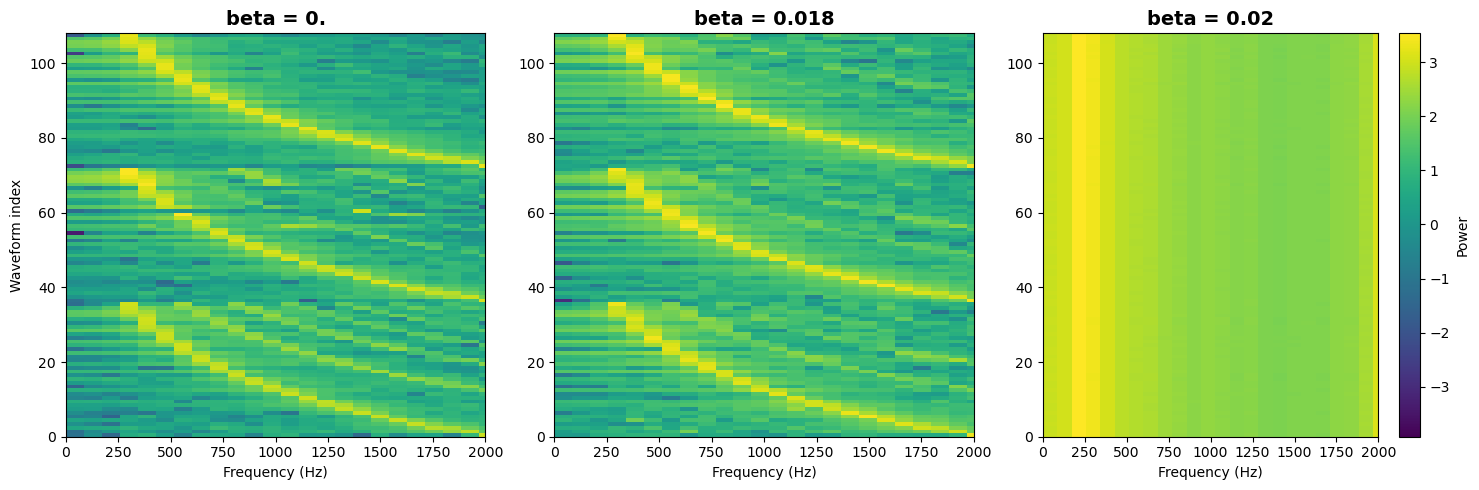

In [49]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Concatenate power spectra for sin, avg, and saw for each model vertically
# ae_power_spectrum_combined = np.vstack([ae_fft_sin_power_spectrum, ae_fft_avg_power_spectrum, ae_fft_saw_power_spectrum])
# good_vae_power_spectrum_combined = np.vstack([good_vae_fft_sin_power_spectrum, good_vae_fft_avg_power_spectrum, good_vae_fft_saw_power_spectrum])
# bae_power_spectrum_combined = np.vstack([bae_fft_sin_power_spectrum, bae_fft_avg_power_spectrum, bae_fft_saw_power_spectrum])

# # Define the number of samples and create a figure
# n_samples_train = ae_power_spectrum_combined.shape[0]  # This includes all 3 stacked waveforms
# fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# # Plot AE model spectrogram (sin, avg, saw stacked vertically)
# im_ae = axs[0].imshow(np.log(ae_power_spectrum_combined[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
#               extent=[frequencies[0], frequencies[input_length // 2 - 1], 0, n_samples_train])
# axs[0].set_title("beta = 0.", fontsize=14, fontweight='bold')
# axs[0].set_xlim(0, 2000)
# axs[0].set_ylabel("Waveform index")
# axs[0].set_xlabel("Frequency (Hz)")

# # Plot good_VAE model spectrogram (sin, avg, saw stacked vertically)
# im_good_vae = axs[1].imshow(np.log(good_vae_power_spectrum_combined[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
#               extent=[frequencies[0], frequencies[input_length // 2 - 1], 0, n_samples_train])
# axs[1].set_title("beta = 0.018", fontsize=14, fontweight='bold')
# axs[1].set_xlim(0, 2000)
# axs[1].set_xlabel("Frequency (Hz)")

# # Plot BAE model spectrogram (sin, avg, saw stacked vertically)
# im_bae = axs[2].imshow(np.log(bae_power_spectrum_combined[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
#               extent=[frequencies[0], frequencies[input_length // 2 - 1], 0, n_samples_train])
# axs[2].set_title("beta = 0.02", fontsize=14, fontweight='bold')
# axs[2].set_xlim(0, 2000)
# axs[2].set_xlabel("Frequency (Hz)")

# # Add colorbar for the last plot (BAE)
# cbar = fig.colorbar(im_bae, ax=axs[2], label='Power')
# plt.savefig("test_interpolations.png", bbox_inches="tight")

# # Adjust layout for better spacing
# plt.tight_layout()
# plt.show()


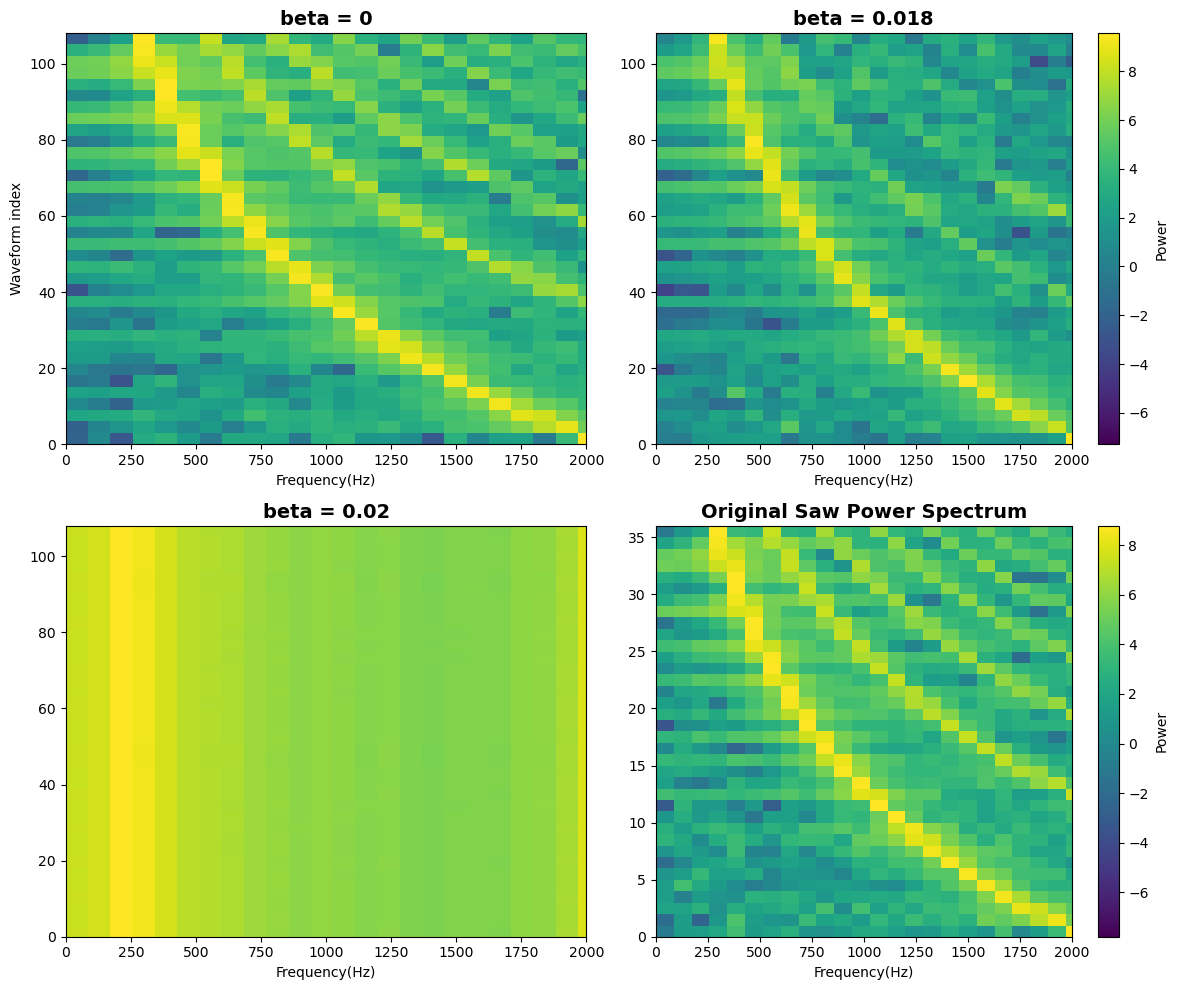

In [50]:
# Create a 2x2 grid for subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))  

# Number of saw waves (assuming all are saw waves now)
n_saw = len(saw_indices)

# AE saw plot (Top-left)
axs[0, 0].imshow(np.log(ae_fft_saw_power_spectrum[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
                 extent=[ae_frequencies[0], ae_frequencies[input_length // 2 - 1], 0, n_samples_train])
axs[0, 0].set_title("beta = 0",fontsize=14, fontweight='bold')
axs[0, 0].set_xlim(0, 2000)
axs[0, 0].set_ylabel("Waveform index")
axs[0, 0].set_xlabel("Frequency(Hz)")

# VAE saw plot (Top-right)
im_bae = axs[0, 1].imshow(np.log(good_vae_fft_saw_power_spectrum[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
                          extent=[vae_frequencies[0], vae_frequencies[input_length // 2 - 1], 0, n_samples_train])
axs[0, 1].set_title("beta = 0.018",fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel("Frequency(Hz)")
axs[0, 1].set_xlim(0, 2000)
# Add colorbar for the VAE saw plot (beta = 0.018)
fig.colorbar(im_bae, ax=axs[0, 1], label='Power')

# BAE saw plot (Bottom-left)
axs[1, 0].imshow(np.log(bae_fft_saw_power_spectrum[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
                 extent=[bae_frequencies[0], bae_frequencies[input_length // 2 - 1], 0, n_samples_train])
axs[1, 0].set_title("beta = 0.02",fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel("Frequency(Hz)")
axs[1, 0].set_xlim(0, 2000)

# Original saw power spectrum plot (Bottom-right)
im_saw = axs[1, 1].imshow(np.log(power_spectrum_saw[:, :input_length // 2] + 1e-10), aspect='auto', cmap='viridis',
                          extent=[frequencies_saw[0], frequencies_saw[input_length // 2 - 1], 0, n_saw])
axs[1, 1].set_title("Original Saw Power Spectrum",fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel("Frequency(Hz)")
axs[1, 1].set_xlim(0, 2000)
# Add colorbar for the original saw power spectrum
fig.colorbar(im_saw, ax=axs[1, 1], label='Power')

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig("test.png", bbox_inches="tight")
plt.show()
